In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm
from helpers_nw import compute_N
from helpers_nw import *

In [2]:
'''
# Set the constants
T0 = 1.0                      # planar channel temperature
Uw = 0.1                      # wall velocity
Np = 50000                    # particles 
L = 1.0                       # distance between plates 
Tw = 1.0                      # wall temperature
m = 1.0                       # mass of argon 
k = 1.0                       # Boltzmann constant
tau = 0.05                    # relaxation time 
t = 0                         # initial time
t_end = 5.0                     # final time normally 5
dt = 0.001                    # timestep
Nsteps = int(t_end // dt) + 1 # number of steps
Nc = 10                       # number of cells
dx = L / Nc                   # space grid length
Tbar = 1.0                    # Correlated 
correlated_process = True
'''

'\n# Set the constants\nT0 = 1.0                      # planar channel temperature\nUw = 0.1                      # wall velocity\nNp = 50000                    # particles \nL = 1.0                       # distance between plates \nTw = 1.0                      # wall temperature\nm = 1.0                       # mass of argon \nk = 1.0                       # Boltzmann constant\ntau = 0.05                    # relaxation time \nt = 0                         # initial time\nt_end = 5.0                     # final time normally 5\ndt = 0.001                    # timestep\nNsteps = int(t_end // dt) + 1 # number of steps\nNc = 10                       # number of cells\ndx = L / Nc                   # space grid length\nTbar = 1.0                    # Correlated \ncorrelated_process = True\n'

In [3]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          # = 0.316 wall velocity
tau = 2 * Kn / np.sqrt(np.pi / 2)     # ≈ 0.225 relaxation time

# Domain
L = 1.0
Nc = 50
dx = L / Nc                            # = 0.02

# Particles
Np = 250000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 10.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 2 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = False

In [4]:
def compute_weights_NW(X, x_grid, h):
    """Compute NW weight matrix once, reuse everywhere."""
    diff = (X[None, :] - x_grid[:, None]) / h  # Nc x Np
    W = np.exp(-0.5 * diff**2)
    W /= W.sum(axis=1, keepdims=True)
    return W  # Nc x Np

def compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):
    Nc = W.shape[0]
    if Mbar is not None:
        W_col_sum = W.sum(axis=0)  # Np
        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]  # Np x 3
        M_corrected = M - Mbar + Ubar_at_X
    else:
        M_corrected = M
    
    U = W @ M_corrected             # Nc x 3
    
    T = np.zeros(Nc)
    for c in range(Nc):
        residuals = M_corrected - U[c]
        T[c] = (m / (3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()
        if Mbar is not None and Tbar is not None:
            T[c] += Tbar
    
    return U, T

In [5]:
def evolve_velocity_M(M, mask, U_particle, T_particle, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_particle) * np.exp(-dt/tau) \
            + U_particle \
            + np.sqrt((k * T_particle / m) * (1 - np.exp(-2*dt/tau)))[:, None] * noise



def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise):
    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
               + dt * N[mask] \
               + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * np.mean(N[mask]**2, axis=0), 0.0)) * noise
    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))

In [6]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        # Reflect particle back to boundary
        X[left_mask] = -L/2
        # Re-sample velocity
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        M[left_mask, 0] = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        M[left_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)

        Mbar[left_mask, 0] = np.sqrt(-2*k*Tbar/m * np.log(r1_left))
        Mbar[left_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        # same for right wall

    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        M[right_mask, 0] = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        M[right_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)

        Mbar[right_mask, 0] = -np.sqrt(-2*k*Tbar/m * np.log(r1_right))
        Mbar[right_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        # same for right wall


    return left_mask, right_mask

In [7]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

Ubar = np.zeros((Nc, 3))

h = 4 * dx
W = compute_weights_NW(X, x_grid, h)

#W = compute_weights_NW(X, x_grid, h)
if correlated_process:
    #Ubar = W @ Mbar  # compute initial Ubar
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
else:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)


#if correlated_process:
#    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
#else:
#    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)

#print("After init - T[0]:", T[0][:5])
#print("After init - U[0]:", U[0][:5])
#U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)


for step in tqdm(range(1, Nsteps)):

    #print(f"Step {step}: max|Mbar| = {np.abs(Mbar).max():.4f}, max|M| = {np.abs(M).max():.4f}")


    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 
    
    # Compute weights once per step
    W = compute_weights_NW(X, x_grid, h)
    
    # Sort particles 
    if correlated_process:    
        N = compute_N(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)

    # For debugging

        if step in [1, 10, 100, 500]:
            print(f"Step {step}:")
            print(f"  mean(N[:,0]) = {np.mean(N[:,0]):.4f}")
            print(f"  mean(N[:,1]) = {np.mean(N[:,1]):.4f}")
            print(f"  mean(N[:,2]) = {np.mean(N[:,2]):.4f}")
            print(f"  std(N[:,0])  = {np.std(N[:,0]):.4f}")
            print(f"  std(N[:,1])  = {np.std(N[:,1]):.4f}")
            print(f"  std(N[:,2])  = {np.std(N[:,2]):.4f}")
            print(f"  max|N|       = {np.abs(N).max():.4f}")
            print(f"  std(Mbar[:,0]) = {np.std(Mbar[:,0]):.4f}")
            alpha = compute_alpha(M, Mbar, W, dx)
            cbar = compute_cbar(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)
            print(f"  std(alpha) = {np.std(alpha):.4f}")
            print(f"  std(cbar)  = {np.std(cbar):.4f}")
            print(f"  max|cbar|  = {np.abs(cbar).max():.4f}")
    
    # Interpolate U and T to each particle position
    #U_at_particle = W.T @ U[step-1]   # Np x 3
    #T_at_particle = W.T @ T[step-1]   # Np

    W_col_sum = W.sum(axis=0)  # Nc x Np summed over Nc -> shape (Np,)
    T_at_particle = (W.T @ T[step-1]) / W_col_sum   # Np
    U_at_particle = (W.T @ U[step-1]) / W_col_sum[:, None]  # Np x 3

    # For debugging
    #if step == 1:
    #    print(np.mean(T_at_particle))
    #    print(np.mean(T[step-1]))

    mask_update = ~mask_wall # exclude wall-hitting particles, because they are already handled  
    
    # Evolve V^i
    noise = np.random.normal(0,1,size=M[mask_update].shape) # Common noise
    evolve_velocity_M(M, mask_update, U_at_particle[mask_update], T_at_particle[mask_update], dt, tau, m, k, noise)

    
    
    if correlated_process:
        evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise)
        #Ubar = W @ Mbar 
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar)

100%|█████████████████████████████████████████| 999/999 [06:16<00:00,  2.65it/s]


In [8]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

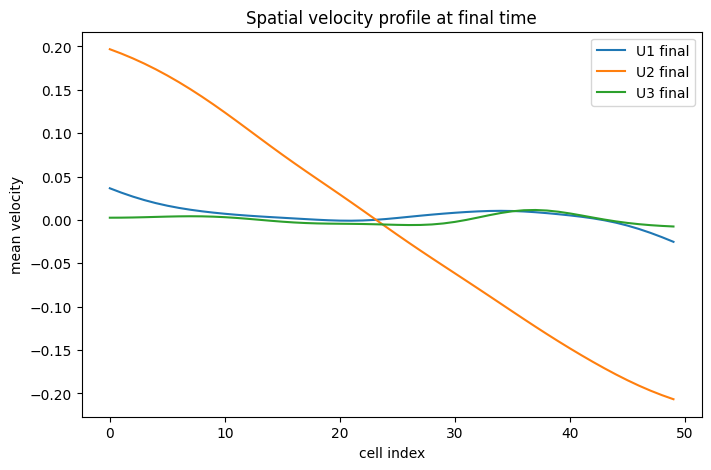

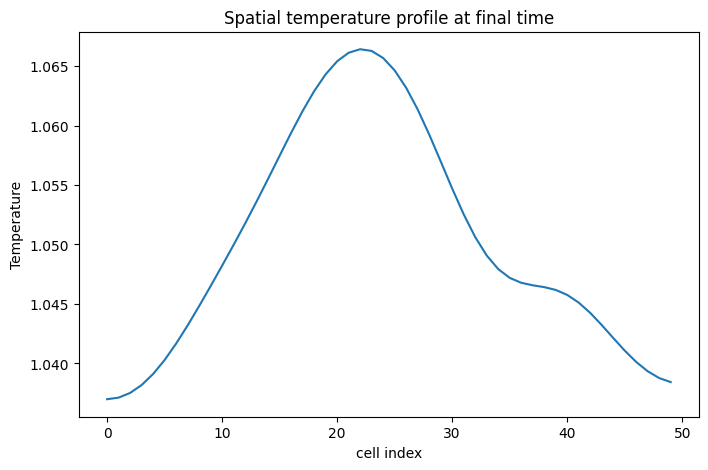

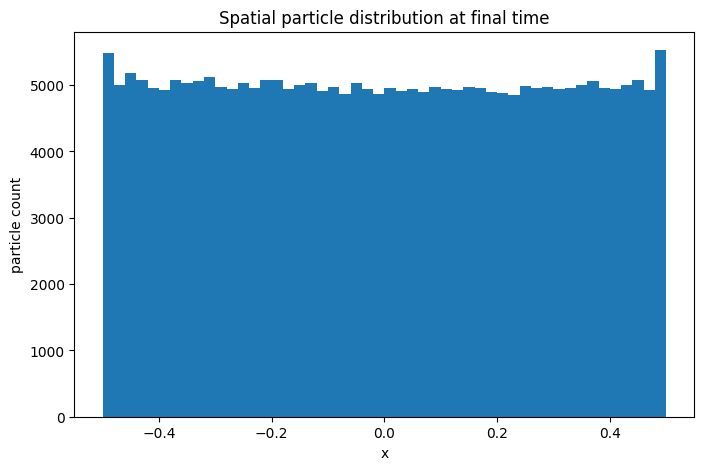

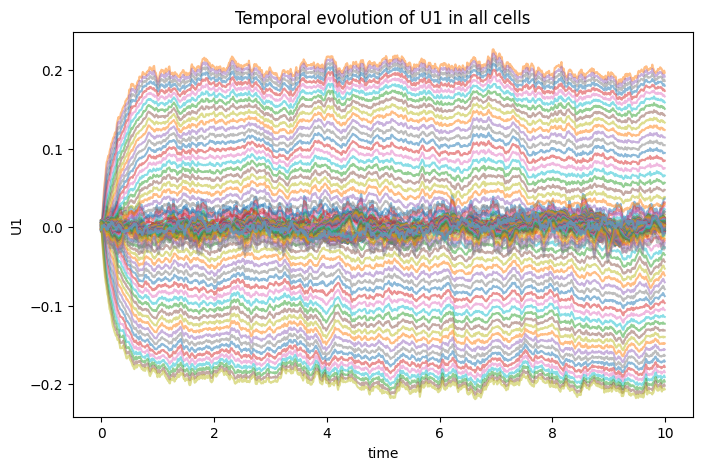

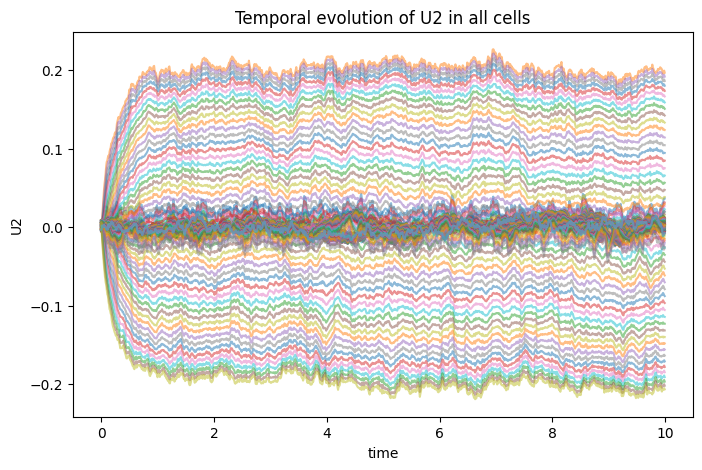

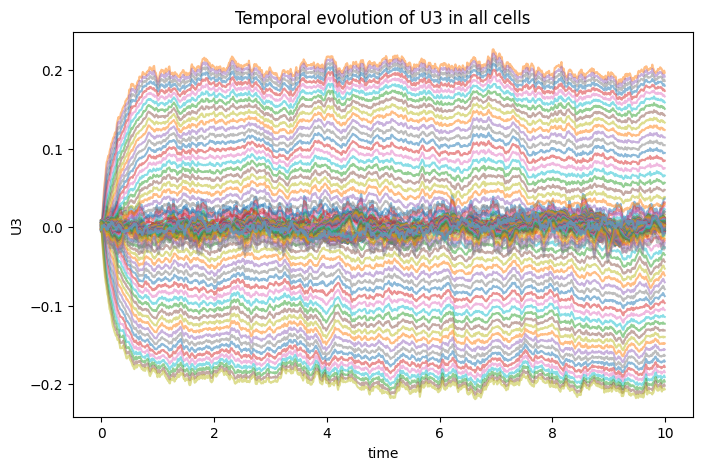

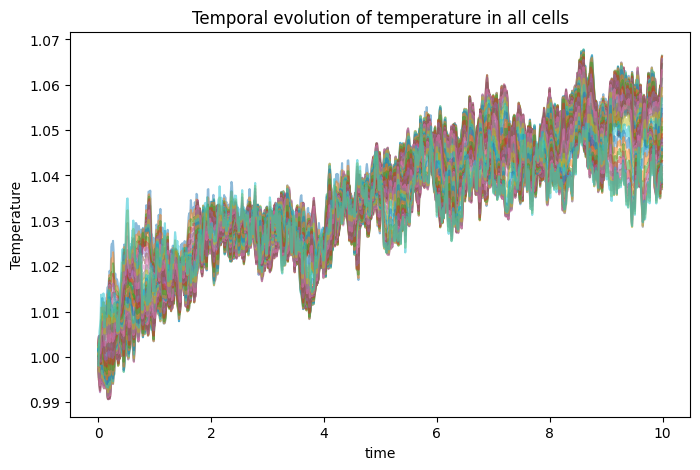

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.hist(X, bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()

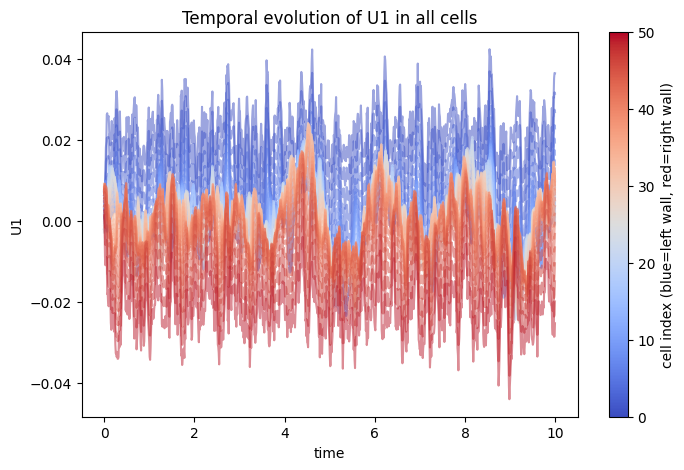

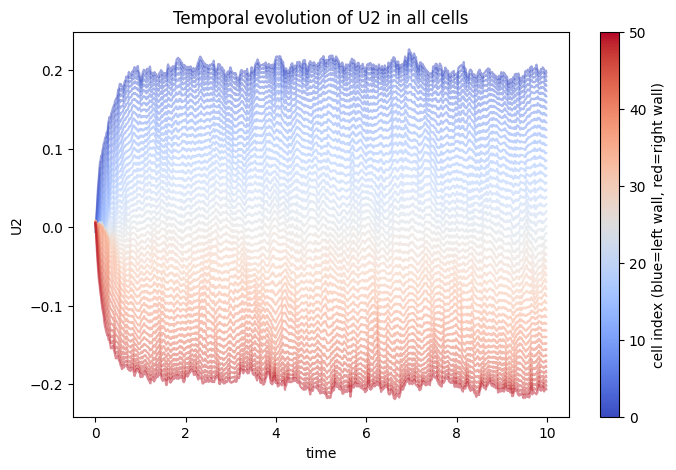

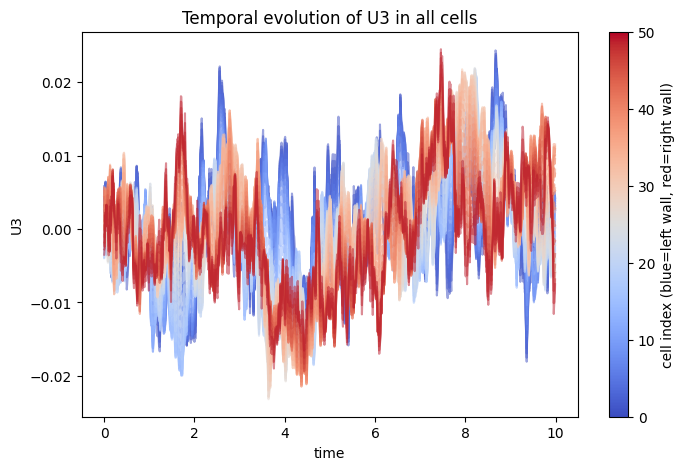

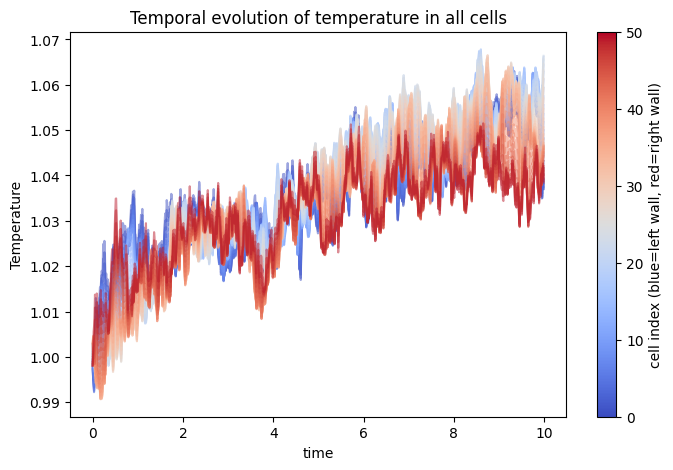

In [10]:
# Temporal U1
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,0], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U1')
ax.set_title('Temporal evolution of U1 in all cells')
plt.show()

# Temporal U2
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,1], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U2')
ax.set_title('Temporal evolution of U2 in all cells')
plt.show()

# Temporal U3
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,2], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U3')
ax.set_title('Temporal evolution of U3 in all cells')
plt.show()

# Temporal temperature
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('Temperature')
ax.set_title('Temporal evolution of temperature in all cells')
plt.show()

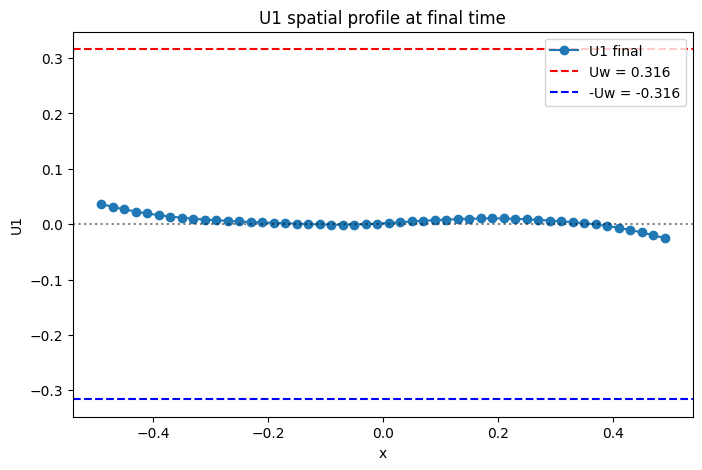

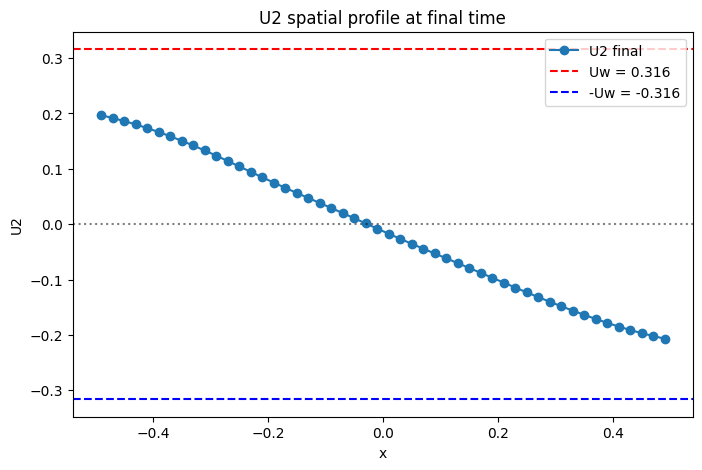

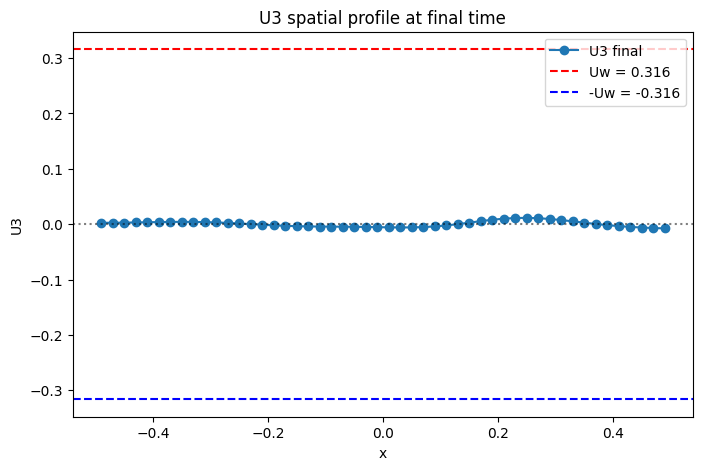

In [11]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 0], 'o-', label='U1 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U1')
plt.title('U1 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 2], 'o-', label='U3 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U3')
plt.title('U3 spatial profile at final time')
plt.legend()
plt.show()

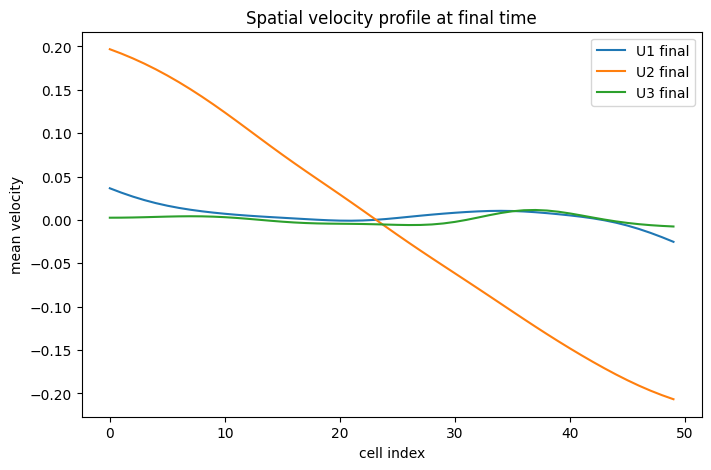

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

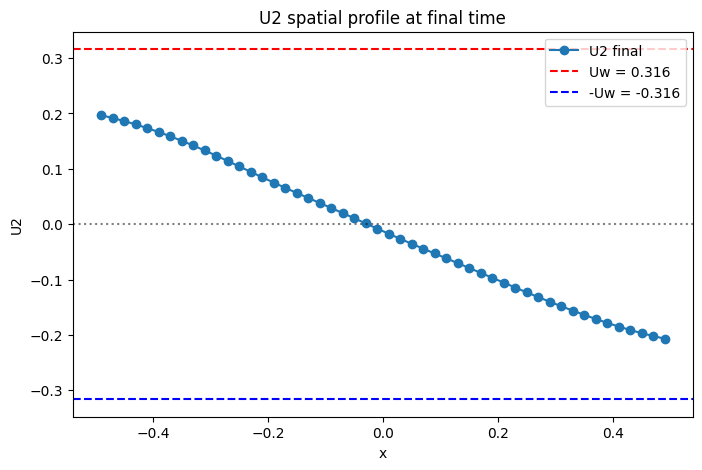

In [13]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()

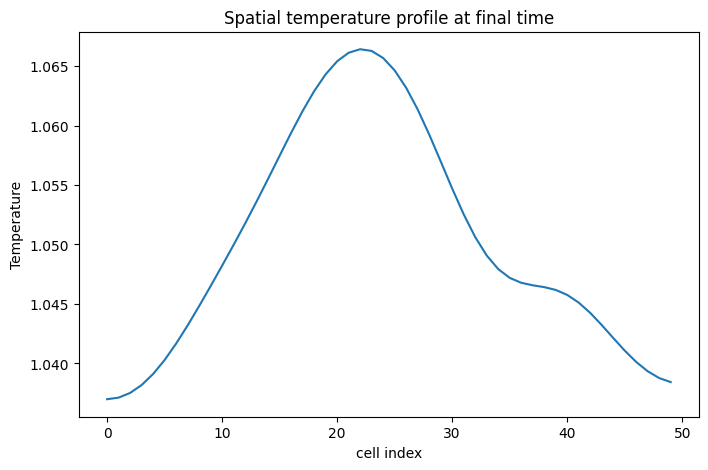

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()